# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:**
**Student ID:**
**Section:**
**GitHub:** https://github.com/usmanasad-droid/
**Kaggle:** https://www.kaggle.com/code/usmanasad0/
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [ ]:
# Task 1 — load and verify the cleaned dataset
df = pd.read_csv('clean_churn.csv')
print(df.shape)
print("Missing values count")
print(df.isnull().sum())
print("datatypes" )
print(df.dtypes)

(7032, 19)
Missing values count
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64
datatypes
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Churn                ob

**Answer 2 (Lab 3/4 recap):**
_Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1):_

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy | 0.7832 | 0.7854 | 0.7939 |
| Precision | 0.6131 | 0.5027 | 0.6458 |
| Recall | 0.5000 | 0.6184 | 0.4973 |
| F1-score | 0.5508 | 0.5546 | 0.5619 |

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [ ]:
# Task 3 — define X and y (same as Lab 3/4)
# transforming Yes No categorical columns to 1 and 0
y = df['Churn'].map({"Yes": 1, "No": 0})
X = df.drop(columns=['Churn'])
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
  X[col] = X[col].map({"Yes" : 1, "No" : 0})
# transforming gender column separately since it doesnt have yes no
X['gender'] = X['gender'].map({'Female' : 1, 'Male' : 0})

# Transform other categorical columns
cols = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=cols, drop_first=True ,dtype=int)

print(f"X shape: {X.shape}")
print(f"Non numeric columns: {len(X.select_dtypes(exclude=["number"]).columns)}")
print(f"Missing values count: {X.isnull().sum().sum()}")


X shape: (7032, 22)
Non numeric columns: 0
Missing values count: 0


**Answer 4:**
KNN measures distances, and Logistic Regression uses math where big numbers (like $100 charges) completely overpower small numbers (like 0 or 1)

Trees just ask simple yes/no questions one feature at a time like "is charges > 50?"), so the size of the numbers doesn't matter to them.

In [ ]:
# Task 5 — train/test split, then fit/apply StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Answer 5 (why fit scaler on training data only):**
_only use scaler on training, if you use on test and training together, test set's distribution can get into train set which can cause data leakage_

---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [ ]:
# Task 6 — train Logistic Regression, predict on scaled test set
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train_scaled, y_train)
y_pred = logistic_regression.predict(X_test_scaled)

Accuracy: 0.7932
Precision: 0.6334
Recall: 0.5267
F1-score: 0.5752


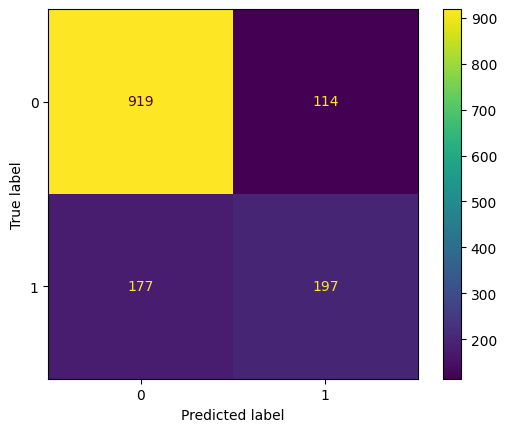

In [ ]:
# Task 7 — metrics + confusion matrix
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_regression.classes_)
disp.plot()
plt.show()

**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7932 |
| Precision | 0.6334 |
| Recall | 0.5267 |
| F1-score | 0.5752 |

In [ ]:
# Task 8 — inspect predict_proba for a few test customers
predict_proba = logistic_regression.predict_proba(X_test_scaled[:10])
print(predict_proba)

[[0.986132   0.013868  ]
 [0.8560079  0.1439921 ]
 [0.29299929 0.70700071]
 [0.85893633 0.14106367]
 [0.68666562 0.31333438]
 [0.61106229 0.38893771]
 [0.85575022 0.14424978]
 [0.23765395 0.76234605]
 [0.76420188 0.23579812]
 [0.98025859 0.01974141]]


**Answer 8:**
_In predict_proba, each row displays the model's predicted probability of a customer belonging to class 0 No Churn versus class 1 Churn which will always sum to 1.0. predict() compares the class 1 probability to a 0.50 cutoff, if it is 0.50 or higher, like customer 3 at 0.71, it assigns a 1 ("Yes"), otherwise, it assigns a 0 ("No")_

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [ ]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)
  y_pred = knn.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  results.append({'K': k, 'Accuracy': acc, 'F1': f1})

results_df=pd.DataFrame(results)
print(results_df)

    K  Accuracy        F1
0   1  0.710021  0.471503
1   3  0.752665  0.527174
2   5  0.748401  0.512397
3   7  0.750533  0.514523
4   9  0.756219  0.526897
5  11  0.761194  0.540984
6  15  0.764748  0.550882
7  21  0.765458  0.550409


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|---|---|---|
| 1 | 0.7100 | 0.4715 |
| 3 |0.7526 | 0.5272 |
| 5 |0.7484 | 0.5124 |
| 7 |0.7505 | 0.5145 |
| 9 |0.7562 | 0.5268 |
| 11 |0.7612 | 0.5410 |
| 15 |0.7647 | 0.5509 |
| 21 |0.7655 | 0.5504 |

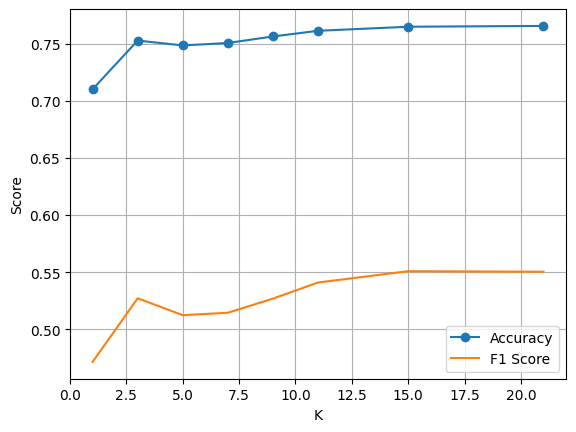

In [ ]:
# Task 10 — plot accuracy/F1 vs K
plt.plot(results_df['K'], results_df['Accuracy'], marker='o',label = "Accuracy")
plt.plot(results_df['K'], results_df['F1'], label = "F1 Score")
plt.xlabel('K')
plt.ylabel('Score')
plt.grid()
plt.legend()
plt.show()

**Answer 10 (chosen K and why):**
_Chosing K=15, it has highest F1 Score 0.5509 and 2nd highest accuracy: 0.7647_

Why not the smallest K =1? It checks just 1 neighbor, so it memorizes random noise instead of real patterns. That's why it has the worst scores

Why not largest K = 21? It checks too many neighbors, so the larger group (people who stay) ends up outvoting and ignoring the churners. That's why the F1-score stopped improving and started dropping.

Accuracy: 0.7647
Precision: 0.5592
Recall: 0.5428
F1-score: 0.5509


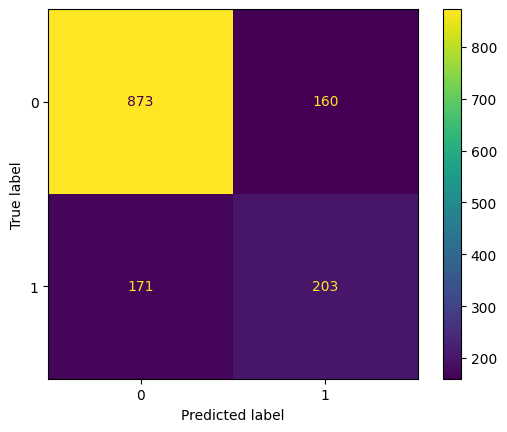

In [ ]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
best_k = 15
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_knn = final_knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=final_knn.classes_)
disp_knn.plot()
plt.show()

**Task 11 — Final KNN Metrics (K = 15)**

| Metric | Value |
|---|---|
| Accuracy | 0.7647 |
| Precision | 0.5592 |
| Recall | 0.5428 |
| F1-score | 0.5509 |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [ ]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [0.7832, 0.6131, 0.5000, 0.5508],
    'Random Forest (tuned)': [0.7939, 0.6458, 0.4973, 0.5619],
    'Logistic Regression': [0.7932, 0.6334, 0.5267, 0.5752],
    'KNN (K=15)': [0.7647, 0.5592, 0.5428, 0.5509]
}

comparison_df = pd.DataFrame(comparison_data).set_index('Metric')
comparison_df

,Decision Tree,Random Forest (tuned),Logistic Regression,KNN (K=15)
Metric,,,,
Accuracy,0.7832,0.7939,0.7932,0.7647
Precision,0.6131,0.6458,0.6334,0.5592
Recall,0.5000,0.4973,0.5267,0.5428
F1-score,0.5508,0.5619,0.5752,0.5509


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
|---|---|---|---|---|
| Accuracy | 0.7832 | 0.7939 | 0.7932 | 0.7647 |
| Precision | 0.6131 | 0.6458 | 0.6334 | 0.5592 |
| Recall | 0.5000 | 0.4973 | 0.5267 | 0.5428 |
| F1-score | 0.5508 | 0.5619 | 0.5752 | 0.5509 |

**Answer 13:**
_Logistic Regression performs best overall because it secures the highest F1-score (0.5752) while maintaining near-peak accuracy (0.7932) and a strong balance across precision (0.6334) and recall (0.5267)._

_Yes ranking does change depending on metrics:_
Precision: Random Forest tuned wins (0.6458), followed closely by Logistic Regression (0.6334). Choose this if false alarms are expensive (e.g., you don't want to waste budget offering discounts to customers who were never going to leave).

Recall: KNN (K=15) ranks highest (0.5428), with Logistic Regression right behind (0.5267). Choose this if the cost of losing a customer completely outweighs annoying a non-churner.

Accuracy: Random Forest (0.7939) and Logistic Regression (0.7932) are tied for top spot, but accuracy is the least informative metric here.

F1-score (or Recall) should carry the most weight. Because 73% of customers do not churn, a naive model predicting zero churn for everyone would achieve 73% accuracy while catching zero churners. In churn prevention, missing an actual leaving customer (False Negative) is almost always far more damaging than incorrectly flagging a loyal customer (False Positive). F1-score provides the most reliable single benchmark by penalizing models that trade off either precision or recall too aggressively.

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [ ]:
# Task 14 — extract coefficients, compute odds ratios
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_regression.coef_[0],
    'Odds Ratio': np.exp(logistic_regression.coef_[0])
})

# Sort by absolute impact
# A large negative number has just as much predictive power as a large positive number so focus strictly on feature importance regardless of direction
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

coef_df.head(10)

,Feature,Coefficient,Odds Ratio
4,tenure,-0.849094,0.427802
9,InternetService_Fiber optic,0.652834,1.920977
18,Contract_Two year,-0.557330,0.572736
10,InternetService_No,-0.464127,0.628684
7,MonthlyCharges,-0.454916,0.634502
17,Contract_One year,-0.312772,0.731416
16,StreamingMovies_Yes,0.231799,1.260866
15,StreamingTV_Yes,0.222421,1.249097
8,MultipleLines_Yes,0.173257,1.189172
11,OnlineSecurity_Yes,-0.152610,0.858464


**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| tenure | -0.8491 |0.4278 | For each standard deviation increase in tenure, the odds of churning decrease by ~57% ($1 - 0.4278$). Longer-term customers are much less likely to leave |
|InternetService_Fiber optic |0.6528 |1.9210 | Customers with Fiber Optic internet have 1.92 times the odds of churning (+92%) compared to the baseline DSL group |
| Contract_Two year	|-0.5573 |0.5727 |Having a two-year contract reduces the odds of churning by ~43% ($1 - 0.5727$) compared to a month-to-month contract. |
| InternetService_No	|-0.4641 |0.6287 |Customers with no internet service have ~37% lower odds ($1 - 0.6287$) of churning compared to the baseline DSL group. |

**Answer 15:**
Yes, the primary drivers mostly agree, with minor differences in how they are represented:

_Agreements: tenure, Contract type (Two year), and InternetService (Fiber optic) were the dominant features in both Lab 2's EDA and Lab 3's Decision Tree. All models show that customers who are new, on short-term contracts, or using fiber optic service carry the highest churn risk._

_Difference:
In the earlier labs, high monthly charges looked like a huge direct cause of churn. Here, the specific services (like Fiber Optic) take the spotlight instead because they are the real reason the bills are high._

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
_I choose Logistic Regression as the final model because it delivers the strongest overall performance on the imbalanced churn class, earning the highest F1-score (0.5752) alongside balanced precision (0.6334) and recall (0.5267). While Random Forest edged ahead slightly in single-split accuracy (0.7939 vs. 0.7932) and precision (0.6458), Lab 4’s cross-validation lesson taught us that a tiny fraction on a single train-test split is often noise rather than true superiority. Logistic Regression provides a more dependable balance across both classes while offering clear, interpretable odds ratios for business action_

**Answer 17 — Conclusion:**
_Logistic Regression beats Labs 3–4’s tuned Random Forest on F1-score and recall, identifying more churners overall. Feature scaling was crucial; without it, unscaled features broke the model and forced it to predict zero churners. Its main limitation is assuming linear relationships, and a recall of ~53% still leaves nearly half the churners undetected._

---

## Submission Checklist

Before submitting, confirm you have:

- [✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [✓] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [✓] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [✓] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [✓] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [✓] Section 5 — Model Comparison (all four models, all four metrics)
- [✓] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [✓] Section 7 — Final Model Selection & Conclusion
- [✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted